In [82]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import classification_logistic
from importlib import reload
reload(classification_logistic)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import pickle

In [48]:
spam_data=pd.read_csv("spam.csv",encoding="latin-1")
spam_data


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [88]:
y=spam_data["v1"]
y=y.map({"ham":0,"spam":1})
message=spam_data["v2"]
tfid=TfidfVectorizer()
X=tfid.fit_transform(message)

,00,000,000pes,008704050406,0089,0121,01223585236,01223585334,0125698789,02,...,ó_,û_,û_thanks,ûªm,ûªt,ûªve,ûï,ûïharry,ûò,ûówell
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [50]:
x_train,x_,y_train,y_=train_test_split(X,y,test_size=0.4,random_state=55)
x_val,x_test,y_val,y_test=train_test_split(x_,y_,test_size=0.5,random_state=55)

In [51]:
degrees=[1,2,3,4,5]

In [52]:
min_split_size=[10,20,100,20,300,400,500,600,700]


In [55]:
accuracy_train=[]
accuracy_val=[]
#choose best min split size in randomforest
for min_split in min_split_size:
    model=RandomForestClassifier(min_samples_split=min_split,random_state=1234).fit(x_train,y_train)
    y_train_predict=model.predict(x_train)
    y_val_predict=model.predict(x_val)
    acc_train=accuracy_score(y_train,y_train_predict)
    acc_val=accuracy_score(y_val,y_val_predict)
    accuracy_train.append(acc_train)
    accuracy_val.append(acc_val)


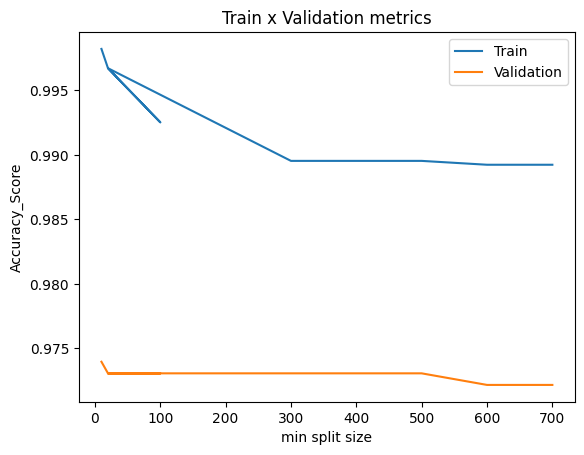

In [56]:
#plot graph pf train and validation accuracy
plt.plot(min_split_size,accuracy_train)
plt.plot(min_split_size,accuracy_val)
plt.ylabel('Accuracy_Score')
plt.xlabel('min split size')
plt.title('Train x Validation metrics')
plt.legend(['Train','Validation'])

In [60]:
#find index with max val accuracy
index=np.argmax(r2_val)
min_split=min_split_size[index]
min_split

10

In [71]:
#list of max
max_depth_list=[2,4,8,16,32,64,100,128,200,None]



In [72]:
accuracy_train_list=[]
accuracy_val_list=[]
for depth_max in max_depth_list:
    model=RandomForestClassifier(max_depth=depth_max,min_samples_split=min_split,random_state=1234)
    model.fit(x_train,y_train)
    y_train_cap=model.predict(x_train)
    y_val_cap=model.predict(x_val)
    accuracy_train_list.append(accuracy_score(y_train,y_train_cap))
    accuracy_val_list.append(accuracy_score(y_val,y_val_cap))

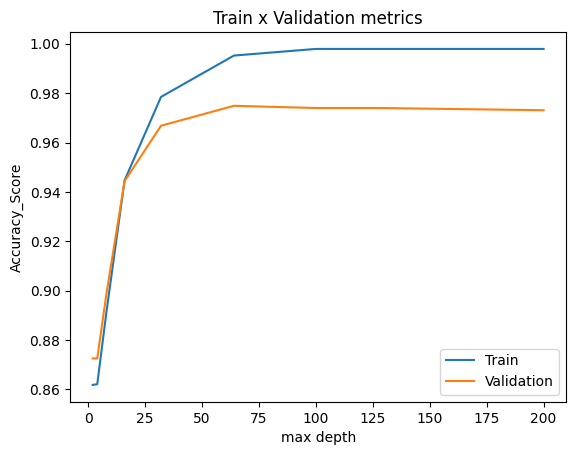

In [73]:
#plot graph pf train and validation accuracy
plt.plot(max_depth_list,accuracy_train_list)
plt.plot(max_depth_list,accuracy_val_list)
plt.ylabel('Accuracy_Score')
plt.xlabel('max depth')
plt.title('Train x Validation metrics')
plt.legend(['Train','Validation'])

In [74]:
index=np.argmax(accuracy_val_list)
max_depth=max_depth_list[index]
max_depth

64

In [75]:
#list of all estimator list
n_estimator_list=[10,100,200,300,400]


In [77]:
accuracy_train_list=[]
accuracy_val_list=[]
for n_estimator in n_estimator_list:
    model=RandomForestClassifier(n_estimators=n_estimator,min_samples_split=min_split,max_depth=max_depth)
    model.fit(x_train,y_train)
    y_train_predict=model.predict(x_train)
    y_val_predict=model.predict(x_val)
    accuracy_train_list.append(accuracy_score(y_train,y_train_predict))
    accuracy_val_list.append(accuracy_score(y_val,y_val_predict))
    


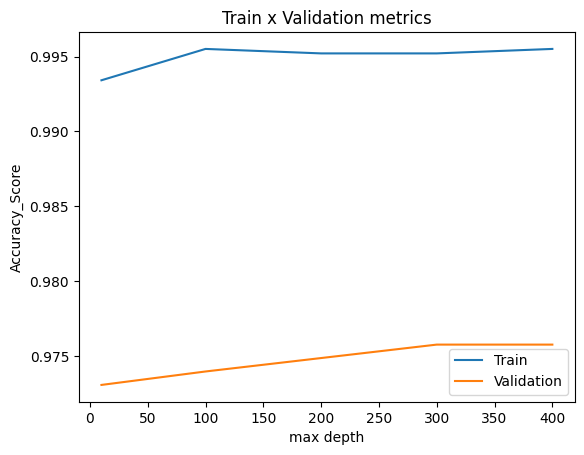

In [78]:
#plot graph pf train and validation accuracy
plt.plot(n_estimator_list,accuracy_train_list)
plt.plot(n_estimator_list,accuracy_val_list)
plt.ylabel('Accuracy_Score')
plt.xlabel('max depth')
plt.title('Train x Validation metrics')
plt.legend(['Train','Validation'])

In [79]:
index=np.argmax(accuracy_val_list)
n_estimator=n_estimator_list[index]
n_estimator

300

In [80]:
model=RandomForestClassifier(n_estimators=n_estimator,min_samples_split=min_split,max_depth=max_depth)
model.fit(x_train,y_train)


,n_estimators,300
,criterion,'gini'
,max_depth,64
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [84]:
pickle.dump(model,open("spam_tree_ensemble.pkl","wb"))